# Healthcare Appointment Cancellation Analytics

## Predictive Modeling and Operational Insights

### Jose Reyes  
MS Business Analytics & Artificial Intelligence  
University of Texas Rio Grande Valley



# Table of Contents

1. Business Problem
2. Dataset Preparation
3. Initial Data Exploration
4. Cancellation Trend Analysis
5. Operational Analysis
6. Data Visualization
7. Data Cleaning & Feature Engineering
8. Machine Learning Models
9. Model Comparison
10. Feature Importance Analysis
11. Patient Age Segmentation
12. Conclusions and Recommendations
13. Limitations
14. Future Enhancements

# Business Problem

Healthcare appointment cancellations negatively impact:
- Provider utilization
- Revenue generation
- Staffing efficiency
- Scheduling operations

This project analyzes operational and patient-related factors associated with appointment cancellations and develops predictive machine learning models to support proactive intervention strategies.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier



# Dataset Generation and Preparation

A synthetic healthcare appointment scheduling dataset was created to simulate a real-world operational analytics environment.

The dataset includes:
- Patient demographics
- Scheduling lead times
- Appointment types
- Representative information
- Workflow completion indicators
- Historical cancellation behavior

The target variable is:
- `Cancelled` (Yes/No)

In [62]:
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "Appointment_ID": range(1000, 1000+n),
    "Rep_Name": np.random.choice(["Maria", "John", "Sarah", "David", "Lisa"], n),
    "Days_Out": np.random.randint(1, 30, n),
    "Address_Verified": np.random.choice(["Yes", "No"], n, p=[0.8, 0.2]),
    "Tech_Assessment": np.random.choice(["Yes", "No"], n, p=[0.7, 0.3]),
    "Appointment_Type": np.random.choice(["Virtual", "In-Home"], n),
    "Patient_Age": np.random.randint(18, 90, n),
    "State": np.random.choice(["TX", "FL", "CA", "NY"], n),
    "Prior_Cancellations": np.random.randint(0, 5, n),
    "Reminder_Sent": np.random.choice(["Yes", "No"], n, p=[0.85, 0.15])
})

# Create realistic cancellation behavior
df["Cancelled"] = np.where(
    (
        (df["Days_Out"] > 14) |
        (df["Address_Verified"] == "No") |
        (df["Tech_Assessment"] == "No") |
        (df["Prior_Cancellations"] >= 2)
    ),
    np.random.choice(["Yes", "No"], n, p=[0.65, 0.35]),
    np.random.choice(["Yes", "No"], n, p=[0.15, 0.85])
)

# Exploratory Data Analysis (EDA)

The exploratory analysis phase examines:
- Dataset structure
- Summary statistics
- Cancellation distribution
- Operational trends
- Relationships between variables

This step helps identify potential patterns and business insights before predictive modeling.

In [63]:
print(df.head())

   Appointment_ID Rep_Name  Days_Out Address_Verified Tech_Assessment  \
0            1000    David        12              Yes             Yes   
1            1001     Lisa        12              Yes              No   
2            1002    Sarah         4              Yes             Yes   
3            1003     Lisa        16              Yes             Yes   
4            1004     Lisa         4              Yes             Yes   

  Appointment_Type  Patient_Age State  Prior_Cancellations Reminder_Sent  \
0          In-Home           21    FL                    3           Yes   
1          In-Home           34    FL                    3           Yes   
2          In-Home           31    TX                    2           Yes   
3          Virtual           30    TX                    0           Yes   
4          Virtual           24    TX                    1            No   

  Cancelled  
0        No  
1       Yes  
2        No  
3       Yes  
4        No  


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Appointment_ID       1000 non-null   int64 
 1   Rep_Name             1000 non-null   object
 2   Days_Out             1000 non-null   int64 
 3   Address_Verified     1000 non-null   object
 4   Tech_Assessment      1000 non-null   object
 5   Appointment_Type     1000 non-null   object
 6   Patient_Age          1000 non-null   int64 
 7   State                1000 non-null   object
 8   Prior_Cancellations  1000 non-null   int64 
 9   Reminder_Sent        1000 non-null   object
 10  Cancelled            1000 non-null   object
dtypes: int64(4), object(7)
memory usage: 86.1+ KB


In [65]:
df.describe()

,Appointment_ID,Days_Out,Patient_Age,Prior_Cancellations
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1499.500000,15.349000,53.187000,1.999000
std,288.819436,8.402964,20.593837,1.417395
min,1000.000000,1.000000,18.000000,0.000000
25%,1249.750000,8.000000,35.000000,1.000000
50%,1499.500000,15.000000,53.000000,2.000000
75%,1749.250000,23.000000,71.000000,3.000000
max,1999.000000,29.000000,89.000000,4.000000


## Cancellation Trend Analysis

The overall cancellation rate establishes the severity of the operational problem and provides context for later machine learning modeling.

In [66]:
df["Cancelled"].value_counts()

,count
Cancelled,
Yes,587
No,413


In [67]:
df["Cancelled"].value_counts(normalize=True)

,proportion
Cancelled,
Yes,0.587
No,0.413


# Operational Analysis

This section investigates operational variables potentially associated with appointment cancellations.

## Scheduling Lead Time Analysis

Scheduling lead time (`Days_Out`) was analyzed to determine whether appointments scheduled further in advance were associated with increased cancellation risk.

Findings suggest:
- cancelled appointments were scheduled slightly further into the future on average
- longer scheduling windows may contribute to patient attrition

In [68]:
df.groupby("Cancelled")["Days_Out"].mean()

,Days_Out
Cancelled,
No,14.704600
Yes,15.802385


## Address Verification Analysis

Address verification was evaluated as a potential operational factor influencing appointment retention.

Normalized cancellation rates were used instead of raw counts to avoid misleading conclusions caused by unequal group sizes.

Findings indicate:
- verified addresses were associated with slightly lower cancellation rates

In [69]:
pd.crosstab(
    df["Address_Verified"],
    df["Cancelled"],
    normalize="index"
)

Cancelled,No,Yes
Address_Verified,,
No,0.371585,0.628415
Yes,0.422277,0.577723


## Technical Assessment Completion

Technical assessment completion was analyzed to determine whether pre-appointment preparation is associated with lower cancellation rates.

In [70]:
pd.crosstab(
    df["Tech_Assessment"],
    df["Cancelled"],
    normalize="index"
)

Cancelled,No,Yes
Tech_Assessment,,
No,0.382911,0.617089
Yes,0.426901,0.573099


## Reminder Sent

Reminder activity was analyzed to evaluate its relationship with cancellation behavior. Results should be interpreted cautiously because reminders may be targeted toward higher-risk appointments.

In [71]:
pd.crosstab(
    df["Reminder_Sent"],
    df["Cancelled"],
    normalize="index"
)

Cancelled,No,Yes
Reminder_Sent,,
No,0.517483,0.482517
Yes,0.395566,0.604434


## Prior Cancellation History

Prior cancellation history was analyzed to determine whether past behavior is associated with future cancellation risk.

In [72]:
df.groupby("Cancelled")["Prior_Cancellations"].mean()

,Prior_Cancellations
Cancelled,
No,1.900726
Yes,2.068143


## Representative-Level Analysis

Cancellation rates were analyzed across scheduling representatives to identify potential operational variation.

Important consideration:
Differences between representatives may reflect:
- patient mix
- queue assignment
- appointment types
- operational workflows

Representative-level differences should therefore be interpreted cautiously.

In [73]:
pd.crosstab(df["Rep_Name"], df["Cancelled"], normalize="index")

Cancelled,No,Yes
Rep_Name,,
David,0.446602,0.553398
John,0.384211,0.615789
Lisa,0.411765,0.588235
Maria,0.380952,0.619048
Sarah,0.442105,0.557895


# Data Visualization

Visualizations were created to:
- identify operational trends
- compare appointment behaviors
- support stakeholder communication
- improve interpretability of findings

## Cancellation by Appointment Type

This visualization compares cancellation behavior between:
- In-Home appointments
- Virtual appointments

The chart suggests slightly higher cancellation counts among In-Home appointments.

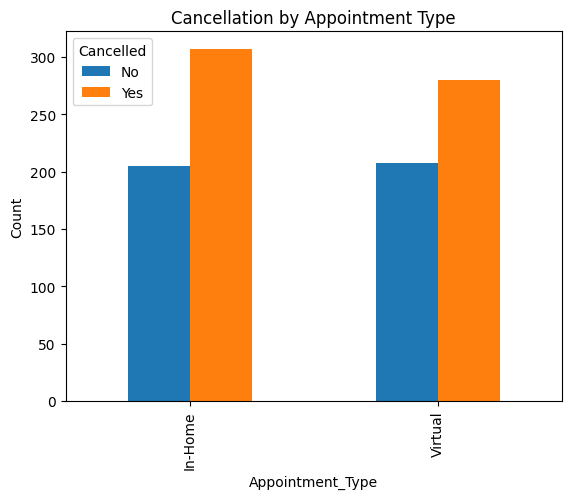

In [74]:

pd.crosstab(
    df["Appointment_Type"],
    df["Cancelled"]
).plot(kind="bar")

plt.title("Cancellation by Appointment Type")
plt.ylabel("Count")
plt.show()

## Distribution of Scheduling Lead Times

The histogram below displays the distribution of appointment scheduling lead times.

Observations:
- appointments are distributed across a wide range of scheduling windows
- no severe outlier patterns are visible

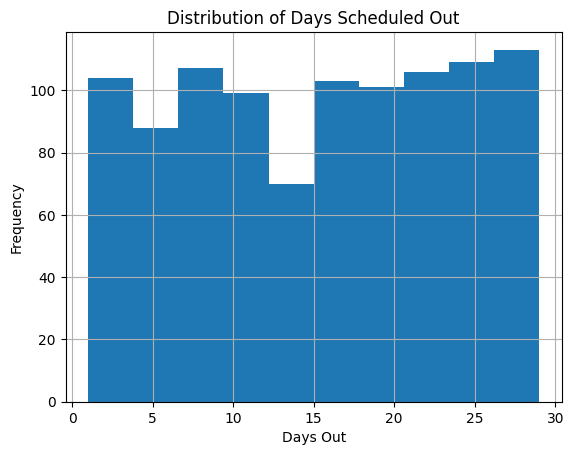

In [75]:
df["Days_Out"].hist()

plt.title("Distribution of Days Scheduled Out")
plt.xlabel("Days Out")
plt.ylabel("Frequency")
plt.show()

## Cancellation Rate by Representative

This chart visualizes cancellation rate differences by representative.

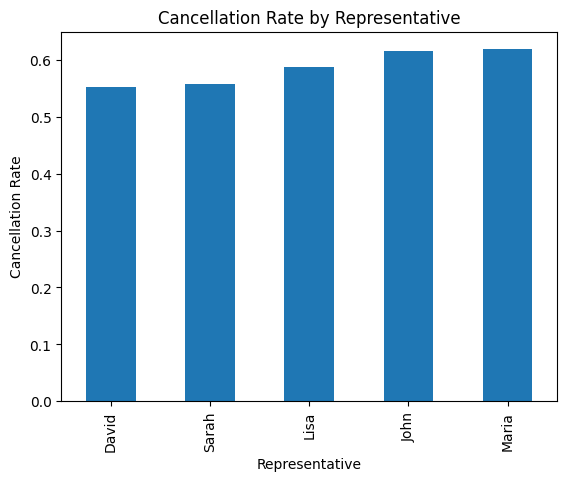

In [76]:
pd.crosstab(
    df["Rep_Name"],
    df["Cancelled"],
    normalize="index"
)["Yes"].sort_values().plot(kind="bar")

plt.title("Cancellation Rate by Representative")
plt.ylabel("Cancellation Rate")
plt.xlabel("Representative")
plt.show()

# Data Cleaning and Feature Engineering

Before machine learning modeling, binary variables were converted to numeric values and categorical variables were encoded.

In [77]:
binary_cols = [
    "Address_Verified",
    "Tech_Assessment",
    "Reminder_Sent",
    "Cancelled"
]

for col in binary_cols:
    df[col] = df[col].map({
        "Yes":1,
        "No":0
    })

df.head()

,Appointment_ID,Rep_Name,Days_Out,Address_Verified,Tech_Assessment,Appointment_Type,Patient_Age,State,Prior_Cancellations,Reminder_Sent,Cancelled
0,1000,David,12,1,1,In-Home,21,FL,3,1,0
1,1001,Lisa,12,1,0,In-Home,34,FL,3,1,1
2,1002,Sarah,4,1,1,In-Home,31,TX,2,1,0
3,1003,Lisa,16,1,1,Virtual,30,TX,0,1,1
4,1004,Lisa,4,1,1,Virtual,24,TX,1,0,0


In [78]:
df_model = pd.get_dummies(
    df,
    columns=["Rep_Name", "Appointment_Type", "State"],
    drop_first=True
)

df_model.head()

,Appointment_ID,Days_Out,Address_Verified,Tech_Assessment,Patient_Age,Prior_Cancellations,Reminder_Sent,Cancelled,Rep_Name_John,Rep_Name_Lisa,Rep_Name_Maria,Rep_Name_Sarah,Appointment_Type_Virtual,State_FL,State_NY,State_TX
0,1000,12,1,1,21,3,1,0,False,False,False,False,False,True,False,False
1,1001,12,1,0,34,3,1,1,False,True,False,False,False,True,False,False
2,1002,4,1,1,31,2,1,0,False,False,False,True,False,False,False,True
3,1003,16,1,1,30,0,1,1,False,True,False,False,True,False,False,True
4,1004,4,1,1,24,1,0,0,False,True,False,False,True,False,False,True


# Machine Learning Models

Several machine learning models were evaluated to predict appointment cancellations.

In [79]:
X = df_model.drop(["Cancelled", "Appointment_ID"], axis=1)
y = df_model["Cancelled"]

## Stratified Train/Test Split

A stratified split was used to preserve cancellation class proportions between:
- training data
- testing data

This improves evaluation reliability and reduces sampling bias.

In [80]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
print("Training Set:")
print(y_train.value_counts(normalize=True))

print("\nTesting Set:")
print(y_test.value_counts(normalize=True))

Training Set:
Cancelled
1    0.5875
0    0.4125
Name: proportion, dtype: float64

Testing Set:
Cancelled
1    0.585
0    0.415
Name: proportion, dtype: float64


## Baseline Logistic Regression

Logistic Regression was used as the baseline classification model because it is interpretable and commonly used for binary classification problems.

In [82]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       0.64      0.19      0.30        83
           1       0.62      0.92      0.74       117

    accuracy                           0.62       200
   macro avg       0.63      0.56      0.52       200
weighted avg       0.63      0.62      0.56       200



## Balanced Logistic Regression

The baseline model showed class prediction imbalance, so a balanced Logistic Regression model was created using `class_weight='balanced'`.

This adjustment helps the model pay more attention to both cancellation outcomes.

In [83]:


balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [84]:
balanced_predictions = balanced_model.predict(X_test)

In [85]:


print(classification_report(
    y_test,
    balanced_predictions
))

              precision    recall  f1-score   support

           0       0.46      0.46      0.46        83
           1       0.62      0.62      0.62       117

    accuracy                           0.55       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.55      0.55      0.55       200



# Random Forest Modeling

A Random Forest classifier was implemented to:
- capture nonlinear relationships
- model interaction effects
- improve predictive performance

Tree-based models are commonly used in operational analytics due to their flexibility and strong predictive capabilities.

In [86]:



rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# Model Evaluation

Model performance was evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score

Because cancellation prediction involves operational tradeoffs, multiple metrics were examined instead of relying solely on accuracy.

In [87]:
print(classification_report(
    y_test,
    rf_predictions
))

              precision    recall  f1-score   support

           0       0.48      0.24      0.32        83
           1       0.60      0.81      0.69       117

    accuracy                           0.57       200
   macro avg       0.54      0.53      0.51       200
weighted avg       0.55      0.57      0.54       200



# Model Comparison

Three machine learning approaches were evaluated:

1. Logistic Regression  
2. Balanced Logistic Regression  
3. Random Forest  

Key observations:
- Logistic Regression served as the baseline model
- Balanced Logistic Regression improved class balance
- Random Forest provided the strongest overall modeling approach because it can capture nonlinear relationships and interaction effects

# Feature Importance Analysis

Feature importance analysis was performed using the Random Forest model to identify the strongest operational drivers of appointment cancellations.

Top predictors included:
- Patient Age
- Days Scheduled Out
- Prior Cancellations
- Tech Assessment Completion

In [88]:


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                     Feature  Importance
3                Patient_Age    0.273079
0                   Days_Out    0.247309
4        Prior_Cancellations    0.121488
2            Tech_Assessment    0.046157
10  Appointment_Type_Virtual    0.043811
1           Address_Verified    0.037462
11                  State_FL    0.031611
13                  State_TX    0.029551
12                  State_NY    0.029155
8             Rep_Name_Maria    0.028828
5              Reminder_Sent    0.028755
9             Rep_Name_Sarah    0.028362
7              Rep_Name_Lisa    0.028219
6              Rep_Name_John    0.026213


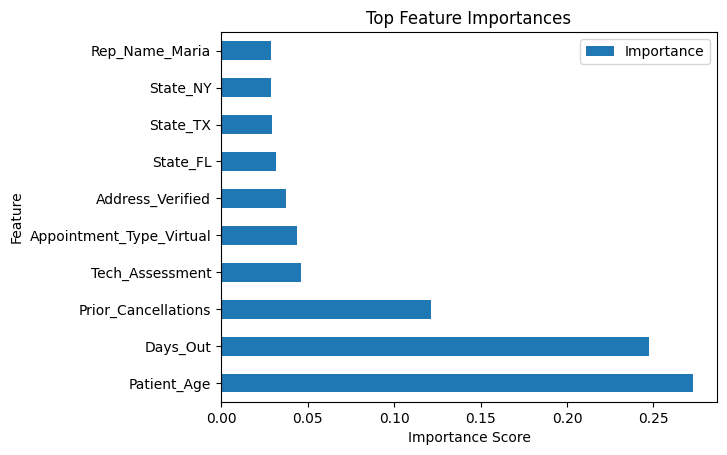

In [89]:
feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Top Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

# Patient Age Segmentation Analysis

Patient ages were segmented into categorical age groups to investigate nonlinear cancellation behavior patterns.

Segmented analysis revealed:
- elevated cancellation rates among patients aged 60 and older

This explains why Patient Age emerged as an important predictive feature.

In [90]:
df.groupby("Cancelled")["Patient_Age"].mean()

,Patient_Age
Cancelled,
0,52.334140
1,53.787053


In [91]:
age_groups = pd.cut(
    df["Patient_Age"],
    bins=[18,30,45,60,75,90]
)

pd.crosstab(
    age_groups,
    df["Cancelled"],
    normalize="index"
)

Cancelled,0,1
Patient_Age,,
"(18, 30]",0.417722,0.582278
"(30, 45]",0.432900,0.567100
"(45, 60]",0.439614,0.560386
"(60, 75]",0.381910,0.618090
"(75, 90]",0.385417,0.614583


# Final Conclusions

This analysis identified several operational factors associated with appointment cancellations.

Key findings:
- Longer scheduling lead times increased cancellation risk
- Prior cancellation history contributed to future cancellations
- Patients aged 60+ demonstrated elevated cancellation rates
- Tech assessment completion was associated with improved appointment retention

Among the evaluated models:
- Random Forest provided the strongest overall predictive performance balance

---

# Business Recommendations

1. Reduce scheduling lead times where operationally feasible
2. Prioritize outreach for patients aged 60+
3. Strengthen address verification procedures
4. Flag patients with prior cancellation history
5. Improve patient engagement during pre-appointment workflows

---

# Future Enhancements

Potential future improvements include:
- SQL integration
- Real-time risk scoring
- Power BI dashboard deployment
- Hyperparameter tuning
- XGBoost implementation
- SHAP explainability analysis

# Limitations

Several limitations should be considered:

- The dataset was synthetically generated
- Human cancellation behavior is difficult to predict
- Additional real-world variables may improve model performance
- Some relationships may reflect operational process effects rather than direct causation
- Reminder activity may be affected by selection bias if reminders are targeted toward high-risk patients

# Future Enhancements

Future improvements could include:

- Power BI dashboard deployment
- SQL database integration
- Hyperparameter tuning
- XGBoost modeling
- SHAP explainability analysis
- Real-time cancellation risk scoring
- Additional variables such as provider availability, weather, appointment urgency, and patient communication history